### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Yuhao Cao
*   Your **student number**: 1004145329



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [99]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [103]:
### YOUR CODE HERE ###

countries = requests.get(countries_list_url, headers=headers).text.strip().splitlines()
countries = [c for c in countries]

df = raw_data[raw_data["entity"].isin(countries)]


df = df[(df["year"] >= 1901) & (df["year"] <= 2023)]


pop_df = df.pivot(index="entity", columns="year", values="population_historical")
pop_df = pop_df.dropna()

pop_df.head()




year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

original population data


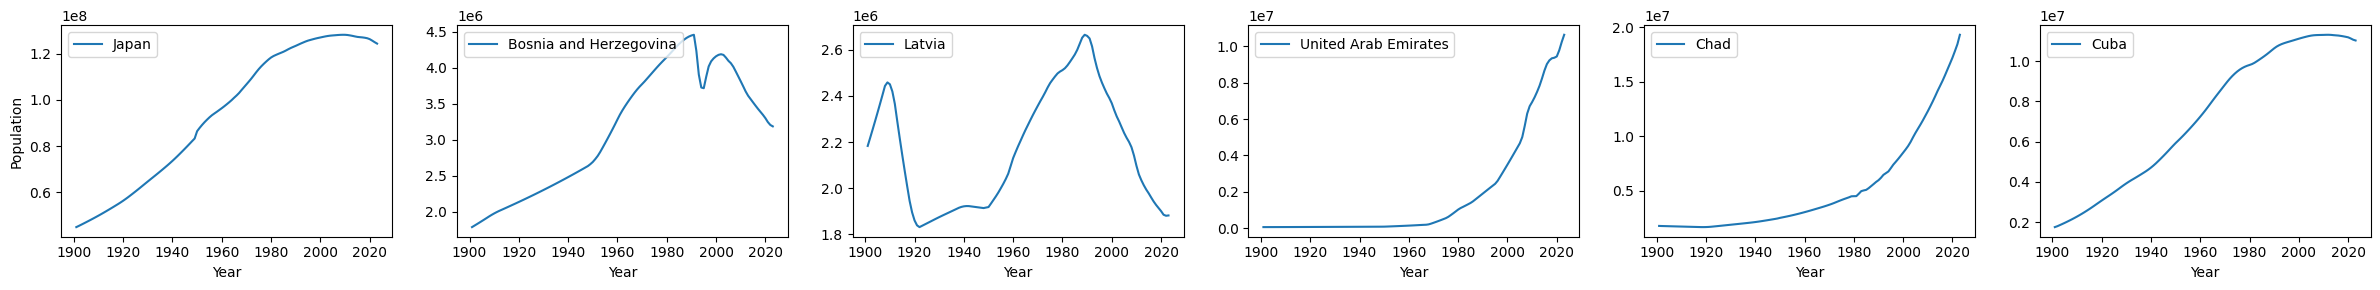

standardized population data


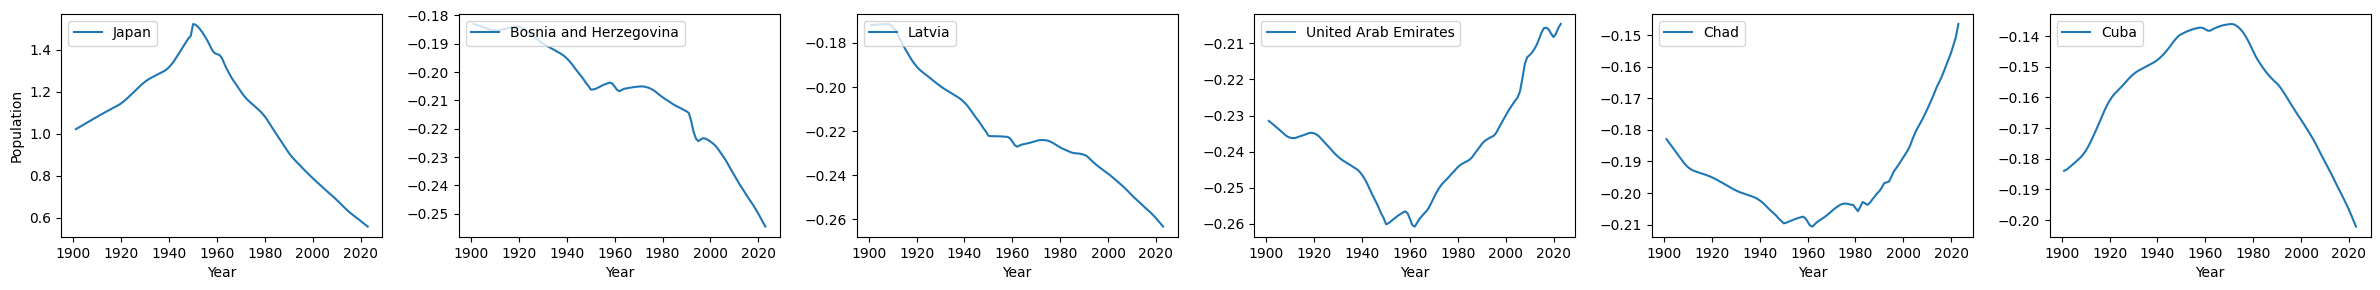

In [105]:
### YOUR CODE HERE ###
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import Levenshtein



def plot_countries(df, countries):
    fig, axes = plt.subplots(1, len(countries), figsize=(4 * len(countries), 3))
    for ax, country in zip(axes, countries):
        ax.plot(df.loc[country].index, df.loc[country].values, label=country)
        ax.legend(loc='upper left')
        ax.set_xlabel('Year')
    axes[0].set_ylabel('Population')
    plt.tight_layout()
    plt.show()


scaler = StandardScaler()
pop_df_scaled = pd.DataFrame(
    scaler.fit_transform(pop_df),   
    index=pop_df.index,             
    columns=pop_df.columns          
)



distances = pop_df.index.to_series().apply(
    lambda country: Levenshtein.distance("yuhao", country.lower())
)

my_countries = distances.nsmallest(2).index.tolist()
countries = ["Japan", "Bosnia and Herzegovina", "Latvia", "United Arab Emirates",*my_countries]

print("original population data")
plot_countries(pop_df, countries)

print("standardized population data")
plot_countries(pop_df_scaled, countries)


Trend:
1. Japan: the standardized score rises until around 1960 and start to drop
2. Bosnia and Herzegovina: the standardized score keeps decreasing since 1900
3. Latvia: the standardized score keeps decreasing since 1900
4. United Arab Emirates: the standardized score decreases until 1950-1960 and then starts to rise
5. Chad: the standardized score decreases until 1960 and then starts to rise
6. Cuba: the standardized score rises until around 1980 and then starts to drop.

Curve movement:
Go up: the population growt is faster than the average of all countries
Go down: the population growt is slower than the average of all countries

Sign:
A positive value means the country's population is above the cross-country mean for that year, and a negative value means below it.